# Part 1: time spent on polyfem matrices generation 

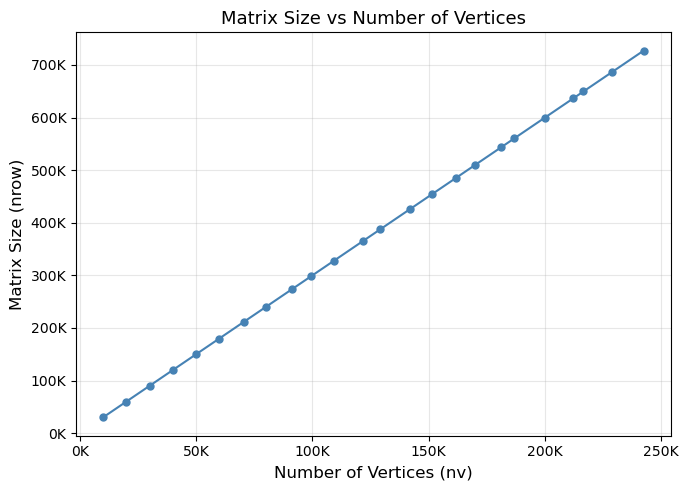

nv range: 9996 – 242373
mat size range: 29988 – 727119


In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt

base = '/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/result_10000-250000-every-10000'

nv_list, mat_size_list = [], []
for nv_str in sorted(os.listdir(base), key=lambda x: int(x)):
    folder = os.path.join(base, nv_str)
    bins = sorted([f for f in os.listdir(folder) if f.endswith('_A.bin')])
    if not bins:
        continue
    fp = os.path.join(folder, bins[0])
    nrow = np.fromfile(fp, dtype=np.int64, count=1, offset=16)[0]
    nv_list.append(int(nv_str))
    mat_size_list.append(int(nrow))

nv_arr = np.array(nv_list)
mat_arr = np.array(mat_size_list)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nv_arr, mat_arr, 'o-', color='steelblue', markersize=5)
ax.set_xlabel('Number of Vertices (nv)', fontsize=12)
ax.set_ylabel('Matrix Size (nrow)', fontsize=12)
ax.set_title('Matrix Size vs Number of Vertices', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"nv range: {nv_arr.min()} – {nv_arr.max()}")
print(f"mat size range: {mat_arr.min()} – {mat_arr.max()}")


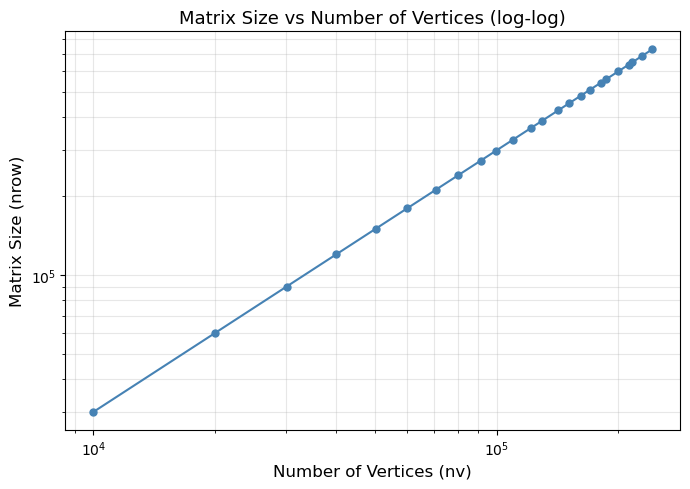

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(nv_arr, mat_arr, 'o-', color='steelblue', markersize=5)
ax.set_xlabel('Number of Vertices (nv)', fontsize=12)
ax.set_ylabel('Matrix Size (nrow)', fontsize=12)
ax.set_title('Matrix Size vs Number of Vertices (log-log)', fontsize=13)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## Difficulty of Generating Matrices at Large Scale

For the largest mesh tested (**nv = 1,124,010**, mat size = **3,372,030 × 3,372,030**, NNZ = **147,417,516**), running on a server with 64 threads:

- **Assembly** takes ~6.7 minutes
- **Linear solve** (Cholesky, `CholmodSupernodalLLT`) takes **~2.3 hours** — dominating 95% of total time
- **Peak memory usage: ~476 GB** out of 1 TB available
- A full Newton solve (typically 6+ iterations per time step) would require **~15 hours per time step**

This makes it infeasible to generate training data at this scale using a direct solver. The matrix size and NNZ both grow linearly with nv, but the Cholesky factorization cost grows super-linearly, making large meshes extremely expensive.


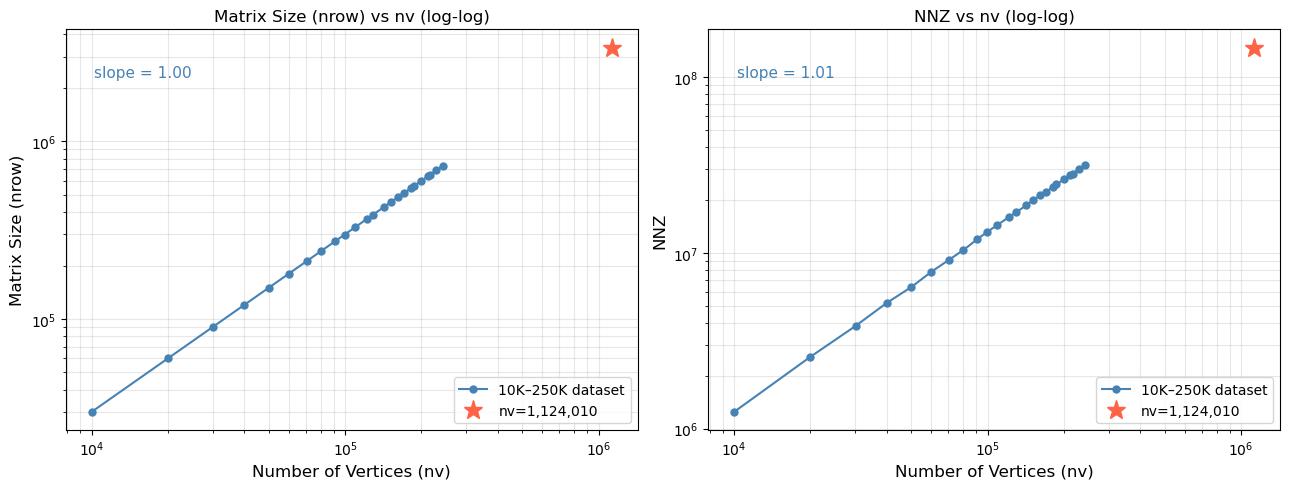

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

base = '/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/result_10000-250000-every-10000'

nv_list, mat_size_list, nnz_list = [], [], []
for nv_str in sorted(os.listdir(base), key=lambda x: int(x)):
    folder = os.path.join(base, nv_str)
    bins = sorted([f for f in os.listdir(folder) if f.endswith('_A.bin')])
    if not bins:
        continue
    fp = os.path.join(folder, bins[0])
    nrow = np.fromfile(fp, dtype=np.int64, count=1, offset=16)[0]
    nnz  = np.fromfile(fp, dtype=np.int64, count=1, offset=32)[0]
    nv_list.append(int(nv_str))
    mat_size_list.append(int(nrow))
    nnz_list.append(int(nnz))

nv_arr  = np.array(nv_list)
mat_arr = np.array(mat_size_list)
nnz_arr = np.array(nnz_list)

# Large matrix data point
fp_large = '/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/result_250000_plus_2/1124010/1_1_A.bin'
nv_large   = 1124010
nrow_large = np.fromfile(fp_large, dtype=np.int64, count=1, offset=16)[0]
nnz_large  = np.fromfile(fp_large, dtype=np.int64, count=1, offset=32)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y, y_large, label in zip(
    axes,
    [mat_arr, nnz_arr],
    [nrow_large, nnz_large],
    ['Matrix Size (nrow)', 'NNZ']
):
    ax.loglog(nv_arr, y, 'o-', color='steelblue', markersize=5, label='10K–250K dataset')
    ax.loglog(nv_large, y_large, '*', color='tomato', markersize=14, label=f'nv=1,124,010')
    ax.set_xlabel('Number of Vertices (nv)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} vs nv (log-log)', fontsize=12)
    ax.grid(True, which='both', alpha=0.3)
    p = np.polyfit(np.log10(nv_arr), np.log10(y), 1)
    ax.annotate(f'slope = {p[0]:.2f}', xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=11, color='steelblue')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [20]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
from libs.parser import parse_log_file

solver_map = {
    "Pardiso": "Eigen::PardisoLDLT",
    "AMGCL": "AMGCL",
    "Hypre": "Hypre",
    "Trilinos": "Trilinos",
}

SOLVER_COLORS = {
    "AMGCL": "#d62728",
    "Eigen::PardisoLDLT": "#1f77b4",
    "Hypre": "#2ca02c",
    "Trilinos": "#ff7f0e",
}

def load_flat_dir(log_dir, num_threads):
    """Load logs from a flat directory (Solver_nv.log format)."""
    data = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for key, val in solver_map.items():
            if fname.startswith(key):
                solver = val
                break
        if solver is None:
            continue
        try:
            entries = parse_log_file(os.path.join(log_dir, fname), solver)
            for e in entries:
                e["num_threads"] = num_threads
            data.extend(entries)
        except Exception as ex:
            print(f"Error: {fname}: {ex}")
    return data

def load_dataset_filter_threads(data_dir, num_threads):
    """Load from golf_ball_N subdirs, filter for specific num_threads."""
    data = []
    for subdir in sorted(os.listdir(data_dir)):
        full = os.path.join(data_dir, subdir)
        if not os.path.isdir(full):
            continue
        try:
            nt = int(subdir.split("_")[-1])
        except ValueError:
            continue
        if nt != num_threads:
            continue
        for fname in sorted(os.listdir(full)):
            if not fname.endswith(".log"):
                continue
            solver = None
            for key, val in solver_map.items():
                if key in fname:
                    solver = val
                    break
            if solver is None:
                continue
            try:
                entries = parse_log_file(os.path.join(full, fname), solver)
                for e in entries:
                    e["num_threads"] = nt
                data.extend(entries)
            except Exception as ex:
                print(f"Error: {fname}: {ex}")
    return data

# Load 2026-3-18 golf_ball_8 data (first_3 + 60_first_3)
data_18 = []
for subdir in ["first_3", "60_first_3"]:
    data_18 += load_dataset_filter_threads(
        f"/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-18/{subdir}", 8)

# Load 2026-3-25 golf_ball_8 data (larger meshes)
data_25 = load_flat_dir(
    "/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-3-25/only_one/golf_ball_8", 8)

def to_df(data):
    return pd.DataFrame([{
        "solver_name": e["solver"],
        "nnz": e["nnz"],
        "elapse_time": e["elapse_time"],
    } for e in data if e.get("nnz") and e.get("elapse_time")])

df18 = to_df(data_18)
df25 = to_df(data_25)

print(f"2026-3-18: {len(df18)} entries, solvers: {sorted(df18['solver_name'].unique())}")
print(f"2026-3-25: {len(df25)} entries, solvers: {sorted(df25['solver_name'].unique())}")


2026-3-18: 504 entries, solvers: ['AMGCL', 'Eigen::PardisoLDLT', 'Hypre', 'Trilinos']
2026-3-25: 18 entries, solvers: ['Hypre', 'Trilinos']


/tmp/ipykernel_2499233/1711412145.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


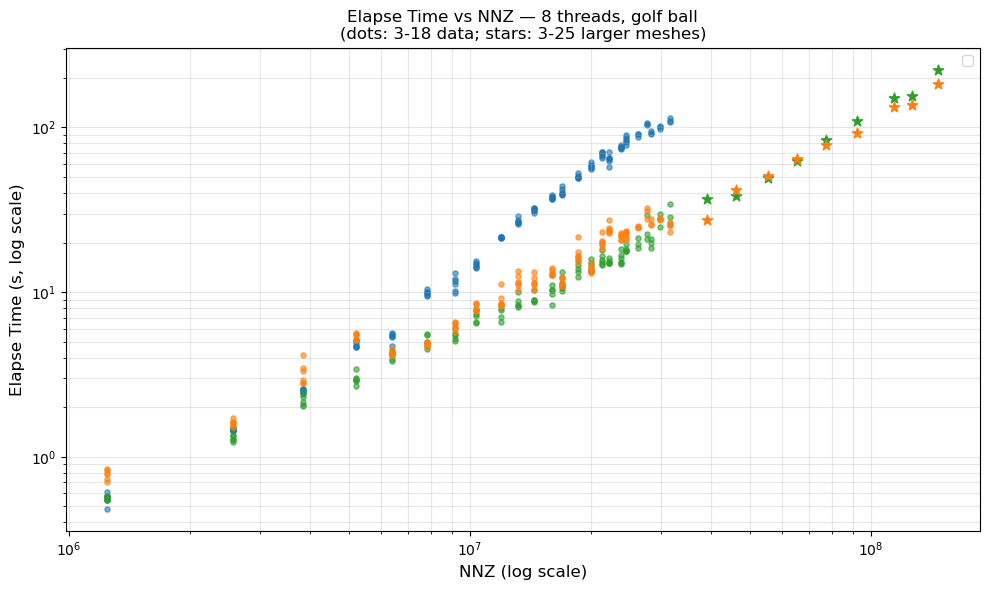

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each solver: 3-18 data (small meshes) + 3-25 data (large meshes) combined
solver_list = sorted(set(df18["solver_name"].unique()) | set(df25["solver_name"].unique()))
solver_list.remove('AMGCL')

for solver in solver_list:
    color = SOLVER_COLORS.get(solver, "gray")

    d18 = df18[df18["solver_name"] == solver]
    d25 = df25[df25["solver_name"] == solver]
    combined = pd.concat([d18, d25])

    # Scatter: distinguish small vs large
    if not d18.empty:
        ax.scatter(d18["nnz"], d18["elapse_time"], s=14, alpha=0.6, color=color)
    if not d25.empty:
        ax.scatter(d25["nnz"], d25["elapse_time"], s=60, marker="*", color=color)

    # Linear fit on log-log (using all data)
    g = combined.groupby("nnz")["elapse_time"].mean().reset_index().sort_values("nnz")
#     if len(g) >= 3:
#         log_x = np.log10(g["nnz"].values)
#         log_y = np.log10(g["elapse_time"].values)
#         coeffs = np.polyfit(log_x, log_y, deg=1)
#         slope = coeffs[0]
#         x_fit = np.logspace(log_x.min(), log_x.max(), 200)
#         y_fit = 10 ** np.polyval(coeffs, np.log10(x_fit))
#         ax.plot(x_fit, y_fit, "--", color=color, linewidth=2,
#                 label=f"{solver} (slope={slope:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("NNZ (log scale)", fontsize=12)
ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
ax.set_title("Elapse Time vs NNZ — 8 threads, golf ball\n(dots: 3-18 data; stars: 3-25 larger meshes)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


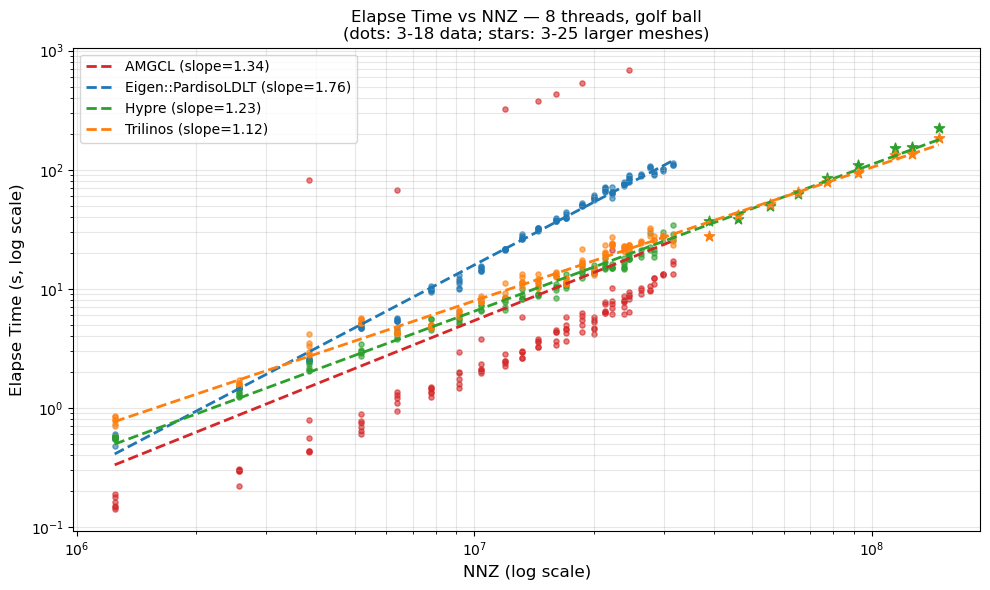

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each solver: 3-18 data (small meshes) + 3-25 data (large meshes) combined
solver_list = sorted(set(df18["solver_name"].unique()) | set(df25["solver_name"].unique()))
# solver_list.remove('AMGCL')

for solver in solver_list:
    color = SOLVER_COLORS.get(solver, "gray")

    d18 = df18[df18["solver_name"] == solver]
    d25 = df25[df25["solver_name"] == solver]
    combined = pd.concat([d18, d25])

    # Scatter: distinguish small vs large
    if not d18.empty:
        ax.scatter(d18["nnz"], d18["elapse_time"], s=14, alpha=0.6, color=color)
    if not d25.empty:
        ax.scatter(d25["nnz"], d25["elapse_time"], s=60, marker="*", color=color)

    # Linear fit on log-log (using all data)
    g = combined.groupby("nnz")["elapse_time"].mean().reset_index().sort_values("nnz")
    if len(g) >= 3:
        log_x = np.log10(g["nnz"].values)
        log_y = np.log10(g["elapse_time"].values)
        coeffs = np.polyfit(log_x, log_y, deg=1)
        slope = coeffs[0]
        x_fit = np.logspace(log_x.min(), log_x.max(), 200)
        y_fit = 10 ** np.polyval(coeffs, np.log10(x_fit))
        ax.plot(x_fit, y_fit, "--", color=color, linewidth=2,
                label=f"{solver} (slope={slope:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("NNZ (log scale)", fontsize=12)
ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
ax.set_title("Elapse Time vs NNZ — 8 threads, golf ball\n(dots: 3-18 data; stars: 3-25 larger meshes)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
